In [74]:
import json

class Battle:
    def __init__(self,file_name):
        with open(file_name,"r") as battle_json:
            data = json.load(battle_json)
        self.log = data["log"]
        self.player_names = [data["players"][0],data["players"][1]]
        self.old_player_ratings = {} # a dictionary where the keys are the player usernames and the values are the player ratings at the start of the match
        self.new_player_ratings = {} # a dictionary where the keys are the player usernames and the values are the player ratings after the end of the match
        self.winner = ""
        self.loser = ""
        self.teams = {self.player_names[0] : set(), self.player_names[1]: set()} # a dictionary where the keys are player usernames and the values are sets containing the pokemon names
        self.time_list = [] # for keeping track of all move times, gets thrown away now.  Could be used to check for time-out forfeits?
        self.start_time = 0
        self.end_time = 0
        self.rated = (data["rating"] != None)
        
        # to get first pokemon
        self.first_pokemon = {player: None for player in self.player_names}

        self.log_parser(self.log)


    def __repr__(self):
        to_return = ""
        if self.rated:
            to_return += f"This was a battle between {self.player_names[0]} (pre-match rating {self.old_player_ratings[self.player_names[0]]}) and {self.player_names[1]} (pre-match rating {self.old_player_ratings[self.player_names[1]]}).\n"
        else:
            to_return += f"This was a battle between {self.player_names[0]} and {self.player_names[1]}.\n"
        for index in range(2):
            to_return += f"{self.player_names[index]}'s team was {self.teams[self.player_names[index]]}.\n"
        to_return += f"{self.winner} won!\n"
        if self.rated:
            to_return += f"{self.winner}'s rating increased to {self.new_player_ratings[self.winner]}.\n"
            to_return += f"{self.loser}'s rating fell to {self.new_player_ratings[self.loser]}."
        else:
            to_return += "This was an unrated match, so no one's rating changed."
        return to_return

    def log_parser(self,log):
        # This loop generates battle information by searching for *all* instances of "|t:|", "|switch|", "|win|", and " for winning)"
        # In particular, it sets the Battle object's new_player_ratings, winner, loser, teams, time_list, and rated attributes.
        for i in range(len(log)):
            # generates time list
            if log.startswith("|t:|",i):
                j = i + 4
                time_string = ""
                while log[j] != "\n":
                    time_string += log[j]
                    j += 1
                self.time_list.append(int(time_string))
            # generate team list
            if log.startswith("|switch|",i):
                pokemon_name = ""
                # Skip to the third pipe in the line.  This is where the species (including forme) is.
                pipe_counter = 0
                j = i
                while pipe_counter < 3:
                    if log[j] == "|":
                        pipe_counter += 1
                    j += 1
                # Now j is the first index after the third pipe in the line
                while log[j] != ",":
                    pokemon_name += log[j]
                    j += 1
                if log.startswith("p1a",i+8):
                    player_name = self.player_names[0]
                else:
                    player_name = self.player_names[1]
                self.teams[player_name].add(pokemon_name)

                if self.first_pokemon[player_name] is None:
                    self.first_pokemon[player_name] = pokemon_name

            # identifies winner and loser
            if log.startswith("|win|",i):
                j = i + 5
                while log[j] != "\n":
                    self.winner += log[j]
                    j += 1
                winner_index = self.player_names.index(self.winner)
                self.loser = self.player_names[1-winner_index]
            if self.rated:
                for player_index in range(2):
                    if log.startswith(f"{self.player_names[player_index]}'s rating: ",i):
                        j = len(self.player_names[player_index]) + 11
                        old_score_string = ""
                        while log[i + j] != " ":
                            old_score_string += log[i+j]
                            j += 1
                        self.old_player_ratings[self.player_names[player_index]] = int(old_score_string)
                        self.new_player_ratings[self.player_names[player_index]] = int(log[i + j + 16:i + j + 16 + len(old_score_string)])
        # We separate start and end time for ease of access
        self.start_time = self.time_list[0]
        self.end_time = self.time_list[-1]

In [75]:
b = Battle('test.json')

In [76]:
# grab a complete pokemon dataset from https://www.kaggle.com/datasets/brdata/complete-pokemon-dataset-gen-iiv

import pandas as pd

pokedex = pd.read_csv('Pokedex_Cleaned.csv', encoding='latin-1')

In [77]:
pdex_by_name = pokedex.set_index('Name')

In [78]:
pdex_by_name.head(100)

,#,Primary Type,Secondary Type,Total,HP,Attack,Defense,Sp.Atk,Sp.Def,Speed,Variant
Name,,,,,,,,,,,
Bulbasaur,1,Grass,Poison,318,45,49,49,65,65,45,NaN
Ivysaur,2,Grass,Poison,405,60,62,63,80,80,60,NaN
Venusaur,3,Grass,Poison,525,80,82,83,100,100,80,NaN
Venusaur,3,Grass,Poison,625,80,100,123,122,120,80,NaN
Charmander,4,Fire,NaN,309,39,52,43,60,50,65,NaN
...,...,...,...,...,...,...,...,...,...,...,...
Golem,76,Rock,Electric,495,80,120,130,55,65,45,Alolan
Golem,76,Rock,Ground,495,80,120,130,55,65,45,NaN
Ponyta,77,Psychic,NaN,410,50,85,55,65,65,90,Galarian


In [79]:
b.player_names

['Goggyo', 'Cygnus11235']

In [80]:
pokemon = b.first_pokemon['Goggyo']

In [81]:
pdex_by_name.loc[pokemon]

,#,Primary Type,Secondary Type,Total,HP,Attack,Defense,Sp.Atk,Sp.Def,Speed,Variant
Name,,,,,,,,,,,
Moltres,146,Dark,Flying,580,90,85,90,100,125,90,Galarian
Moltres,146,Fire,Flying,580,90,100,90,125,85,90,NaN


In [82]:
from pathlib import Path

In [83]:
matches = pd.DataFrame({'p1_pokemon' : [], 'p2_pokemon' : [], 'winner' : []})

In [84]:
matches

,p1_pokemon,p2_pokemon,winner


In [85]:
for file in Path('./gen9-randombattle').iterdir():
    if file.is_file():
        battle = Battle(file)
        matches = pd.concat([matches, pd.DataFrame({'p1_pokemon' : [battle.first_pokemon[battle.player_names[0]]], 'p2_pokemon' : [battle.first_pokemon[battle.player_names[1]]], 'winner' : [battle.winner == battle.player_names[0]]})], ignore_index=True)

In [86]:
matches.head(10)

,p1_pokemon,p2_pokemon,winner
0,Quaquaval,Abomasnow,0.0
1,Greninja,Clefable,0.0
2,Munkidori,Donphan,1.0
3,Sinistcha-Masterpiece,Glimmora,1.0
4,Ambipom,Arceus-Bug,0.0
5,Sudowoodo,Sableye,0.0
6,Appletun,Ambipom,0.0
7,Clodsire,Araquanid,0.0
8,Sandy Shocks,Electivire,1.0
9,Staraptor,Jumpluff,1.0


In [87]:
matches.info()

<class 'pandas.DataFrame'>
RangeIndex: 4798 entries, 0 to 4797
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   p1_pokemon  4798 non-null   object 
 1   p2_pokemon  4798 non-null   object 
 2   winner      4798 non-null   float64
dtypes: float64(1), object(2)
memory usage: 112.6+ KB


In [88]:
matches['p1_pokemon'].value_counts(normalize=True)

p1_pokemon
Raikou                    0.004585
Okidogi                   0.004377
Crabominable              0.003960
Bellibolt                 0.003960
Oranguru                  0.003960
                            ...   
Avalugg-Hisui             0.000208
Alcremie-Rainbow-Swirl    0.000208
Rotom-Wash                0.000208
Deoxys                    0.000208
Florges-Blue              0.000208
Name: proportion, Length: 539, dtype: float64

In [89]:
matches['p2_pokemon'].value_counts(normalize=True)

p2_pokemon
Dragonite               0.004377
Espeon                  0.004377
Amoonguss               0.004168
Sudowoodo               0.003960
Meloetta                0.003960
                          ...   
Minior-Yellow           0.000208
Sawsbuck                0.000208
Pikachu-Original        0.000208
Vivillon-Archipelago    0.000208
Minior-Violet           0.000208
Name: proportion, Length: 541, dtype: float64

In [90]:
matches['p1_pokemon'].value_counts(normalize=False)

p1_pokemon
Raikou                    22
Okidogi                   21
Crabominable              19
Bellibolt                 19
Oranguru                  19
                          ..
Avalugg-Hisui              1
Alcremie-Rainbow-Swirl     1
Rotom-Wash                 1
Deoxys                     1
Florges-Blue               1
Name: count, Length: 539, dtype: int64

In [91]:
import json

# Load the JSON file
with open('pokedex.json', 'r') as f:
    data = json.load(f)

# Normalize the data and flatten nested dictionaries
df = pd.json_normalize(data.values(), sep='_')

# Display the result
print(df.head())

   num           name            types  heightm  weightkg  color        evos  \
0  1.0      Bulbasaur  [Grass, Poison]      0.7       6.9  Green   [Ivysaur]   
1  2.0        Ivysaur  [Grass, Poison]      1.0      13.0  Green  [Venusaur]   
2  3.0       Venusaur  [Grass, Poison]      2.0     100.0  Green         NaN   
3  3.0  Venusaur-Mega  [Grass, Poison]      2.4     155.5  Green         NaN   
4  3.0  Venusaur-Gmax  [Grass, Poison]     24.0       0.0  Green         NaN   

          eggGroups  genderRatio_M  genderRatio_F  ...  cosmeticFormes  maxHP  \
0  [Monster, Grass]          0.875          0.125  ...             NaN    NaN   
1  [Monster, Grass]          0.875          0.125  ...             NaN    NaN   
2  [Monster, Grass]          0.875          0.125  ...             NaN    NaN   
3  [Monster, Grass]          0.875          0.125  ...             NaN    NaN   
4  [Monster, Grass]          0.875          0.125  ...             NaN    NaN   

   requiredAbility  battleOnly  

In [92]:
names = set(df.name)

In [93]:
names

{'Cosmoem',
 'Tangrowth',
 'Gastrodon',
 'Darmanitan',
 'Durant',
 'Arceus-Dark',
 'Wattrel',
 'Coalossal',
 'Buizel',
 'Rotom-Frost',
 'Corsola-Galar',
 'Crabominable-Mega',
 'Kricketune',
 'Gloom',
 'Psyduck',
 'Grumpig',
 'Mareanie',
 'Axew',
 'Volkritter',
 'Charizard',
 'Granbull',
 'Shedinja',
 'Roggenrola',
 'Pikachu-Unova',
 'Slowpoke-Galar',
 'Dugtrio-Alola',
 'Relicanth',
 'Rattata-Alola',
 'Hydreigon',
 'Gallade',
 'Mr. Mime',
 'Reshiram',
 'Magearna-Original',
 'Persian-Alola',
 'Quagsire',
 'Voltorb',
 'Arrokuda',
 'Salazzle-Totem',
 'Surskit',
 'Venusaur',
 'Tauros',
 'Regirock',
 'Polteageist',
 'Spinda',
 'Vivillon-Modern',
 'Loudred',
 'Venomicon',
 'Chuggon',
 'Mantyke',
 'Arboliva',
 'Castform-Snowy',
 'Regigigas',
 'Xatu',
 'Zapdos-Galar',
 'Kingambit',
 'Cinccino',
 'Zubat',
 'Golem-Alola',
 'Arctibax',
 'Swadloon',
 'Typhlosion',
 'Thwackey',
 'Fletchinder',
 'Hoopa-Unbound',
 'Froslass-Mega',
 'Grotle',
 'Tepig',
 'Cobalion',
 'Snubbull',
 'Pupitar',
 'Thundurus'

In [94]:
seen = set(matches['p1_pokemon']).union(set(matches['p2_pokemon']))

In [95]:
for p in seen:
    if p not in names:
        print(p.split('-')[0])

Alcremie
Sawsbuck
Florges
Florges
Florges
Florges
Sawsbuck
Sawsbuck


In [96]:
pokedex = df.set_index('name')

In [ ]:
def get_types(pokemon_name):
    if pokemon_name in names:
        if type(pokedex.loc[pokemon_name, 'types']) == list:
            return pokedex.loc[pokemon_name, 'types']
        # some pokemon with cosmetic variants do not have a type listed in the pokedex, but their base form does.  In this case, we can just split off the cosmetic variant part of the name and look up the base form 
    return pokedex.loc[pokemon_name.split('-')[0], 'types']

In [105]:
import numpy as np

def first_type(pokemon_name):
    types = get_types(pokemon_name)
    return types[0]

def second_type(pokemon_name):
    types = get_types(pokemon_name)
    return types[1] if len(types) > 1 else np.nan

In [106]:
matches.head(1)

,p1_pokemon,p2_pokemon,winner
0,Quaquaval,Abomasnow,0.0


In [107]:
matches['p1_type1'] = matches['p1_pokemon'].apply(lambda x: first_type(x))
matches['p1_type2'] = matches['p1_pokemon'].apply(lambda x: second_type(x))
matches['p2_type1'] = matches['p2_pokemon'].apply(lambda x: first_type(x))
matches['p2_type2'] = matches['p2_pokemon'].apply(lambda x: second_type(x))

In [109]:
matches.head(1)

,p1_pokemon,p2_pokemon,winner,p1_type1,p1_type2,p2_type1,p2_type2
0,Quaquaval,Abomasnow,0.0,Water,Fighting,Grass,Ice


In [114]:
types = set(matches['p2_type1'])
n_matches = len(matches)

In [117]:
for t in types:
    t_wins = matches[((matches['p1_type1'] == t) |  (matches['p1_type2'] == t)) & (matches['winner'] == 1.0)].shape[0]
    t_wins += matches[((matches['p2_type1'] == t) |  (matches['p2_type2'] == t)) & (matches['winner'] == 0.0)].shape[0]

    t_appears = matches[((matches['p1_type1'] == t) |  (matches['p1_type2'] == t))].shape[0] + matches[((matches['p2_type1'] == t) |  (matches['p2_type2'] == t))].shape[0]

    print(t, 'win rate', t_wins / t_appears)

Bug win rate 0.5260586319218241
Grass win rate 0.5090579710144928
Fire win rate 0.486810551558753
Psychic win rate 0.4696321642429427
Rock win rate 0.5087719298245614
Fairy win rate 0.5111111111111111
Dark win rate 0.47255113024757806
Electric win rate 0.5166270783847982
Steel win rate 0.48186528497409326
Flying win rate 0.4781395348837209
Water win rate 0.5089820359281437
Dragon win rate 0.4778761061946903
Ground win rate 0.5094339622641509
Poison win rate 0.5115961800818554
Ice win rate 0.5143824027072758
Ghost win rate 0.48074179743223966
Fighting win rate 0.4891304347826087
Normal win rate 0.508646998982706


In [119]:
print(matches.head(5))

              p1_pokemon  p2_pokemon  winner p1_type1  p1_type2 p2_type1  \
0              Quaquaval   Abomasnow     0.0    Water  Fighting    Grass   
1               Greninja    Clefable     0.0    Water      Dark    Fairy   
2              Munkidori     Donphan     1.0   Poison   Psychic   Ground   
3  Sinistcha-Masterpiece    Glimmora     1.0    Grass     Ghost     Rock   
4                Ambipom  Arceus-Bug     0.0   Normal       NaN      Bug   

  p2_type2  
0      Ice  
1      NaN  
2      NaN  
3   Poison  
4      NaN  


In [123]:
list_types = list(types)

In [124]:
counts = {t1 : {t2 : 0 for t2 in list_types} for t1 in list_types}
wins = {t1 : {t2 : 0 for t2 in list_types} for t1 in list_types}

In [125]:
for t1 in list_types:
    for t2 in list_types:
        counts[t1][t2] += matches[((matches['p1_type1'] == t1) |  (matches['p1_type2'] == t1)) & ((matches['p2_type1'] == t2) |  (matches['p2_type2'] == t2))].shape[0]
        counts[t1][t2] += matches[((matches['p2_type1'] == t1) |  (matches['p2_type2'] == t1)) & ((matches['p1_type1'] == t2) |  (matches['p1_type2'] == t2))].shape[0]

        wins[t1][t2] += matches[((matches['p1_type1'] == t1) |  (matches['p1_type2'] == t1)) & ((matches['p2_type1'] == t2) |  (matches['p2_type2'] == t2)) & (matches['winner'] == 1.0)].shape[0]
        wins[t1][t2] += matches[((matches['p2_type1'] == t1) |  (matches['p2_type2'] == t1)) & ((matches['p1_type1'] == t2) |  (matches['p1_type2'] == t2)) & (matches['winner'] == 0.0)].shape[0]

In [126]:
ratio = {t1 : {t2 : 0 for t2 in list_types} for t1 in list_types}

for t1 in list_types:
    for t2 in list_types:
        ratio[t1][t2] = wins[t1][t2] / counts[t1][t2] if counts[t1][t2] > 0 else np.nan

In [127]:
import seaborn as sns
import matplotlib.pyplot as plt


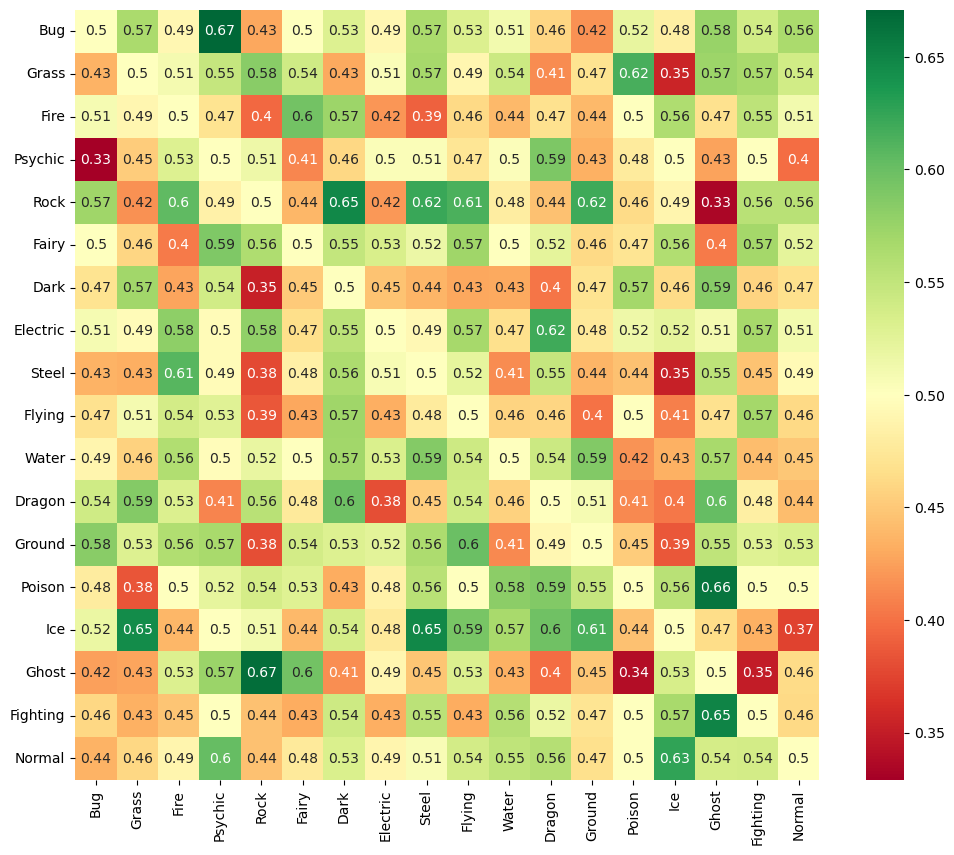

In [130]:
df = pd.DataFrame.from_dict(ratio)

plt.figure(figsize=(12, 10))
sns.heatmap(df.T, annot=True, cmap='RdYlGn')
plt.show()